# create composite figure for the supplementary figure!

In [1]:
# === Setup: load data, fonts, helpers ===
%load_ext autoreload
%autoreload 2

import sys, os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.colors import Normalize
from matplotlib.gridspec import GridSpec
import scanpy as sc
import anndata
from PIL import Image as _PILImage
from datetime import date

notebook_dir = os.path.dirname(os.path.abspath(''))
if notebook_dir not in sys.path:
    sys.path.append(os.path.dirname(notebook_dir))
from notebooks.config import *
configure_matplotlib()

cpm_scl = CPM_SCL

# PDF settings: editable text
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

# Load publication font (TeX Gyre Heros — Helvetica-metric-compatible, see config.py)
font_path = FONT_PATH
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
matplotlib.rcParams['font.family'] = FONT_NAME
matplotlib.rcParams['font.size'] = 7
font_7 = fm.FontProperties(fname=font_path, size=7)

# Oblique/italic face for gene names
oblique_path = os.path.join(FONT_DIR, 'texgyreheros-italic.otf')
if os.path.exists(oblique_path):
    font_8_oblique = fm.FontProperties(fname=oblique_path, size=8)
else:
    font_8_oblique = fm.FontProperties(family=FONT_NAME, size=8, style='oblique')

# Load and preprocess data
print("Loading snRNA-seq data...")
myfilename = os.path.join(SNRNA_DATA_DIR, "snRNAseq_LCNE_BN_d4_1-5k.h5ad")
adata_foo = sc.read_h5ad(myfilename)
adata_foo.obs['sex'] = adata_foo.obs['sex'].replace({
    'M;M;M;M;M;M;M;M;M;M': 'M', 'F;F;F;F;F;F;F;F;F;F': 'F'})
adata_BN = anndata.AnnData(adata_foo.layers['BN'])
adata_BN.obs = adata_foo.obs.copy()
adata_BN.obsm = adata_foo.obsm.copy()
adata_BN.var = adata_foo.var.copy()

adata_sc = adata_BN.copy()
adata_sc.layers['originalBN'] = adata_sc.X.copy()
adata_sc.raw = adata_foo.copy()
sc.pp.scale(adata_sc, zero_center=True, max_value=10)
sc.tl.pca(adata_sc, n_comps=50, svd_solver='arpack')
print(f"Data loaded: {adata_sc.shape}")

def _gene_expr(g):
    return adata_sc.layers["originalBN"][:, np.where(adata_sc.var_names == g)[0][0]]

# Curated gene sets
curated_genes = {
    "Axon guidance": ["Epha6", "Plxna2", "Robo1", "Epha7", "Plxna4", "Sema3c", "Slit2"],
    "Cell adhesion": ["Csmd3", "Il1rapl1", "Lrrtm4", "Ncam2", "Cdh13",
                      "Cdh6", "Cntn4", "Fat3", "Pcdh7", "Sdk2", "Tmem132d"],
    "ECM": ["Chsy3", "Col18a1", "Col6a5", "Hs3st5", "Hs6st3", "Ndst3"],
    "Ion channels": ["Hcn1", "Scn9a", "Kcnh1", "Kctd8"],
    "Neuromodulator signaling": ["Trhr", "Sctr", "Tacr3", "Tafa5", "Pdyn", "Htr2c", "Olfr78"],
    "Neurotransmitter signaling": ["Gabrg1", "Glra2"],
    "Synaptic transmission": ["Cadps2", "Cadps"],
    "Transcription": ["Esr1", "Nrip1", "Tshz1", "Tshz2"],
    "Transporters": ["Slc16a10", "Slc39a12"],
}

# Filter to genes present in the dataset (some may be missing from HVG list)
curated_present = {}
all_missing = []
for cat, genes in curated_genes.items():
    present = [g for g in genes if g in adata_sc.var_names]
    missing = [g for g in genes if g not in adata_sc.var_names]
    if missing:
        all_missing.extend([(cat, g) for g in missing])
    if present:
        curated_present[cat] = present

if all_missing:
    print("Genes NOT found in dataset (excluded):")
    for cat, g in all_missing:
        print(f"  {cat}: {g}")
    print()

for cat, genes in curated_present.items():
    print(f"  {cat}: {len(genes)} panels")
print(f"Total: {sum(len(g) for g in curated_present.values())} panels")
print("Setup complete.")

PROJECT_ROOT: /code/
CODE_DIR: /code/
CODE_DIR exists: True
Python path includes CODE_DIR: True
Loading snRNA-seq data...


/tmp/ipykernel_26979/224540667.py:48: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata_foo.obs['sex'] = adata_foo.obs['sex'].replace({


Data loaded: (4743, 1502)
Genes NOT found in dataset (excluded):
  Cell adhesion: Cdh13
  ECM: Hs3st5
  ECM: Hs6st3
  Neuromodulator signaling: Tafa5
  Neuromodulator signaling: Pdyn
  Neuromodulator signaling: Htr2c
  Synaptic transmission: Cadps

  Axon guidance: 7 panels
  Cell adhesion: 10 panels
  ECM: 4 panels
  Ion channels: 4 panels
  Neuromodulator signaling: 4 panels
  Neurotransmitter signaling: 2 panels
  Synaptic transmission: 1 panels
  Transcription: 4 panels
  Transporters: 2 panels
Total: 38 panels
Setup complete.


Layout: 6 rows (packed from 9 categories)
  Row 1: Cell adhesion(7)
  Row 2: Cell adhesion(3) + ECM(4)
  Row 3: Axon guidance(7)
  Row 4: Ion channels(4) + Neurotransmitter signaling(2) + Synaptic transmission(1)
  Row 5: Neuromodulator signaling(4) + Transporters(2)
  Row 6: Transcription(4)

Figure dimensions (before tight crop): 7.24 x 7.34 inches
Target: 6.50 x 9.00 inches (US Letter portrait, 1" margins)


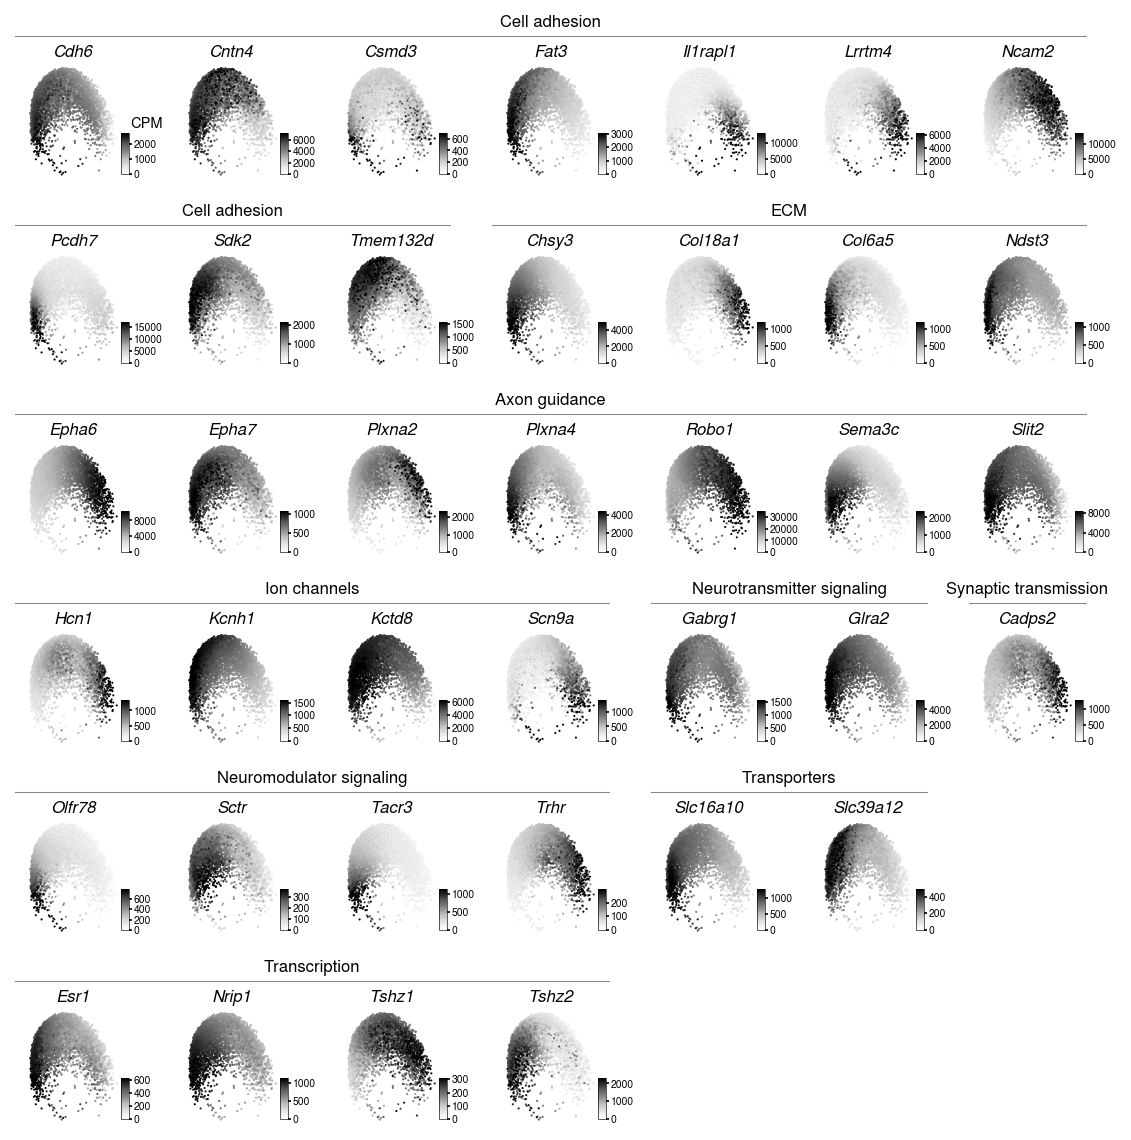


Saved figure dimensions: 7.54 x 7.60 inches
Target (portrait, 1" margins): 6.50 x 9.00 inches
=> Does NOT fit: width over by 1.04", height OK
All-category composite saved.


In [2]:
# === Composite figure: all gene classes, packed into rows ===
# Sort categories by gene count (descending); genes alphabetically within each
sorted_cats = sorted(curated_present.keys(), key=lambda c: len(curated_present[c]), reverse=True)
for cat in curated_present:
    curated_present[cat] = sorted(curated_present[cat])

emb = adata_sc.obsm['X_pca']
max_cols = 7  # 7 columns per row

# --- Bin-packing that splits large categories across rows ---
rows = []  # each row is a list of (cat, genes_subset) tuples
for cat in sorted_cats:
    genes = list(curated_present[cat])
    while genes:
        placed = False
        for row in rows:
            used = sum(len(g) for _, g in row)
            avail = max_cols - used
            if avail >= len(genes):
                row.append((cat, genes))
                genes = []
                placed = True
                break
            elif avail > 0 and len(genes) > max_cols:
                row.append((cat, genes[:avail]))
                genes = genes[avail:]
                placed = True
                break
        if not placed:
            chunk = genes[:max_cols]
            genes = genes[max_cols:]
            rows.append([(cat, chunk)])

n_rows = len(rows)
print(f"Layout: {n_rows} rows (packed from {len(curated_present)} categories)")
for i, r in enumerate(rows):
    cats_str = " + ".join(f"{c}({len(g)})" for c, g in r)
    print(f"  Row {i+1}: {cats_str}")

# --- Panel sizing to fit 6.5" x 9.0" (portrait letter, 1" margins) ---
pw, ph = 0.78, 0.78
col_gap_in = 0.28
row_gap = 0.22               # generous space between rows
header_h = 0.26              # room for category label + underline + gene name
cbar_w_in = 0.05

# Font definitions per spec
font_8_cat = fm.FontProperties(fname=font_path, size=8)           # 8pt for category
font_8_gene = fm.FontProperties(fname=font_path, size=8)          # fallback
if os.path.exists(oblique_path):
    font_8_gene = fm.FontProperties(fname=oblique_path, size=8)   # oblique 8pt for gene
font_7_cpm = fm.FontProperties(fname=font_path, size=7)           # 7pt for CPM label
font_5_tick = fm.FontProperties(fname=font_path, size=5)          # 5pt for tick labels

col_pitch = pw + col_gap_in
left_margin = 0.05
right_margin = 0.05
fig_w = left_margin + max_cols * col_pitch - col_gap_in + right_margin
fig_h = n_rows * (ph + header_h) + (n_rows - 1) * row_gap

row_pitch = ph + header_h + row_gap

print(f"\nFigure dimensions (before tight crop): {fig_w:.2f} x {fig_h:.2f} inches")
print(f"Target: 6.50 x 9.00 inches (US Letter portrait, 1\" margins)")

fig = plt.figure(figsize=(fig_w, fig_h), dpi=150)

def _nice_ticks(vmax, max_ticks=4):
    """Generate clean ticks with at most max_ticks values (including 0)."""
    if vmax <= 0:
        return [0]
    n_intervals = max_ticks - 1
    raw = vmax / n_intervals
    mag = 10 ** int(np.floor(np.log10(max(raw, 1))))
    candidates = [mag * n for n in [1, 2, 5, 10]]
    interval = int(min(candidates, key=lambda c: abs(c - raw)))
    interval = max(interval, 1)
    ticks = list(range(0, int(vmax) + 1, interval))
    ticks = [t for t in ticks if t <= vmax]
    while len(ticks) > max_ticks:
        interval *= 2
        ticks = list(range(0, int(vmax) + 1, interval))
        ticks = [t for t in ticks if t <= vmax]
    if len(ticks) < 2:
        ticks = [0, int(round(vmax))]
    return ticks

is_first_cbar = True

for row_idx, row_cats in enumerate(rows):
    # Panel region (excludes header)
    panel_top_y = 1.0 - (row_idx * row_pitch + header_h) / fig_h
    panel_bottom_y = panel_top_y - ph / fig_h

    # Category label high in header; underline close to label, far from gene name
    cat_label_y = panel_top_y + (header_h * 0.82) / fig_h
    underline_y = panel_top_y + (header_h * 0.68) / fig_h  # close to label, away from gene

    col_offset = 0
    for cat_idx, (cat, genes) in enumerate(row_cats):
        n = len(genes)

        # Category label centered above this group — 8pt
        group_left = (left_margin + col_offset * col_pitch) / fig_w
        group_right = (left_margin + (col_offset + n) * col_pitch - col_gap_in) / fig_w
        lx = (group_left + group_right) / 2
        fig.text(lx, cat_label_y, cat, fontproperties=font_8_cat,
                 ha='center', va='bottom')

        # Underline — closer to class label than to gene label
        fig.add_artist(plt.Line2D(
            [group_left, group_right], [underline_y, underline_y],
            color='#888888', linewidth=0.5,
            transform=fig.transFigure, clip_on=False))

        for col_idx, g in enumerate(genes):
            abs_col = col_offset + col_idx
            left = (left_margin + abs_col * col_pitch) / fig_w
            bottom = panel_bottom_y
            width = pw / fig_w
            height = ph / fig_h

            ax = fig.add_axes([left, bottom, width, height])

            expr = _gene_expr(g)
            order = np.argsort(expr)
            expr_cpm = expr[order] * cpm_scl
            vmax = np.percentile(expr * cpm_scl, 99)
            norm = Normalize(vmin=0, vmax=vmax)

            sca = ax.scatter(
                emb[order, 0], emb[order, 1],
                c=expr_cpm, s=1.0, cmap="Greys",
                norm=norm,
                edgecolor="k", linewidth=0.01,
                rasterized=True,
            )
            ax.set_aspect("equal")
            ax.set_xticks([]); ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_visible(False)

            # Gene name just above panel — oblique 8pt
            gene_label_y = panel_top_y + (header_h * 0.05) / fig_h
            gene_label_x = left + width / 2
            fig.text(gene_label_x, gene_label_y, g, fontproperties=font_8_gene,
                     ha='center', va='bottom')

            # Per-gene colorbar (inside panel, bottom-right)
            cb_left = left + width - cbar_w_in / fig_w - 0.003
            cb_bottom = bottom + 0.05 * height
            cb_width = cbar_w_in / fig_w
            cb_height = 0.35 * height
            cbar_ax = fig.add_axes([cb_left, cb_bottom, cb_width, cb_height])
            cb = plt.colorbar(sca, cax=cbar_ax)

            ticks = _nice_ticks(vmax, max_ticks=4)
            cb.set_ticks(ticks)
            tick_labels = [str(t) for t in ticks]
            cb.set_ticklabels(tick_labels)
            cb.ax.tick_params(labelsize=5, length=1.5, pad=1)
            cb.outline.set_linewidth(0.3)
            for lbl in cb.ax.get_yticklabels():
                lbl.set_fontproperties(font_5_tick)
                lbl.set_ha('left')

            if is_first_cbar:
                # CPM label — 7pt, left-aligned with tick numbers, above colorbar
                cbar_top_y = cb_bottom + cb_height
                fig.text(cb_left + cb_width + 0.001, cbar_top_y + 0.002, 'CPM',
                         fontproperties=font_7_cpm, ha='left', va='bottom')
                is_first_cbar = False

        col_offset += n

out_dir = '/root/capsule/output/figures/snRNAseq/expression_PCA'
os.makedirs(out_dir, exist_ok=True)

fig.savefig(os.path.join(out_dir, 'composite_all_cats.pdf'),
            format='pdf', transparent=True, dpi=500, bbox_inches='tight')
fig.savefig(os.path.join(out_dir, 'composite_all_cats.png'),
            format='png', transparent=True, dpi=500, bbox_inches='tight')
plt.show()

# Report actual saved dimensions
_img = _PILImage.open(os.path.join(out_dir, 'composite_all_cats.png'))
_w, _h = _img.size
_dpi = _img.info.get('dpi', (500, 500))
_fw, _fh = _w / _dpi[0], _h / _dpi[1]
print(f"\nSaved figure dimensions: {_fw:.2f} x {_fh:.2f} inches")
print(f"Target (portrait, 1\" margins): 6.50 x 9.00 inches")
if _fw <= 6.5 and _fh <= 9.0:
    print("=> FITS within portrait letter margins!")
else:
    over_w = f"width over by {_fw - 6.5:.2f}\"" if _fw > 6.5 else "width OK"
    over_h = f"height over by {_fh - 9.0:.2f}\"" if _fh > 9.0 else "height OK"
    print(f"=> Does NOT fit: {over_w}, {over_h}")
print("All-category composite saved.")

In [3]:

out_dir = '/root/capsule/output/figures/snRNAseq/expression_PCA'
today = date.today().strftime('%Y%m%d')

# 300 DPI version — rasterized plots, editable text
fname_300 = f'fig_S9_{today}_300dpi.pdf'
fig.savefig(os.path.join(out_dir, fname_300),
            format='pdf', transparent=True, dpi=300, bbox_inches='tight')

# 600 DPI version — rasterized plots, editable text
fname_600 = f'fig_S9_{today}_600dpi.pdf'
fig.savefig(os.path.join(out_dir, fname_600),
            format='pdf', transparent=True, dpi=600, bbox_inches='tight')

print("Saved:")
for f in [fname_300, fname_600]:
    sz = os.path.getsize(os.path.join(out_dir, f)) / 1e6
    print(f"  {f}  ({sz:.1f} MB)")

Saved:
  fig_S9_20260713_300dpi.pdf  (1.2 MB)
  fig_S9_20260713_600dpi.pdf  (3.1 MB)
